# 03 · Meteorología y demanda

**Trabajo Fin de Máster** · Predicción de demanda en hostelería
Juan Francisco Morales Olivo

---

Este notebook pone a prueba la hipótesis central del proyecto:

> **¿De verdad influye el tiempo en cuánta gente va al restaurante? ¿Y cuánto?**

La respuesta no es obvia. Es fácil suponer que sí, pero hay que medirlo, y hay que medirlo con cuidado: el tiempo está correlacionado con el mes, y el mes está correlacionado con la demanda. Si no se controla, se acaba atribuyendo a la temperatura lo que en realidad es estacionalidad.

In [1]:
# ============================================================
# CONFIGURACIÓN DEL NOTEBOOK
# ============================================================

import sys
from pathlib import Path

# Permite importar `src` desde la carpeta notebooks/
RAIZ = Path.cwd()

if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Proyecto:", RAIZ)

Proyecto: /home/claude/tfm


In [2]:
from src.config import GOLD_DATASET

gold = pd.read_csv(GOLD_DATASET, parse_dates=["fecha"])

gold["amplitud_termica"] = gold["tmax"] - gold["tmin"]

print("METEOROLOGÍA OBSERVADA (Arganda del Rey, estación 3182Y)")
print("-" * 60)
print(gold[["tmed", "tmax", "tmin", "prec", "amplitud_termica"]].describe().round(1).to_string())

METEOROLOGÍA OBSERVADA (Arganda del Rey, estación 3182Y)
------------------------------------------------------------
         tmed    tmax    tmin    prec  amplitud_termica
count  1138.0  1138.0  1138.0  1138.0            1138.0
mean     15.6    22.6     8.7     1.2              13.9
std       7.6     9.1     6.8     4.1               5.0
min       0.6     5.0    -8.5     0.0               2.2
25%       9.4    14.7     3.4     0.0               9.9
50%      14.6    21.0     8.3     0.0              14.4
75%      21.5    29.8    14.0     0.2              18.0
max      33.5    43.6    24.6    78.6              25.1


## 1. Cómo es el clima aquí

Antes de relacionarlo con nada, conviene saber a qué nos enfrentamos.

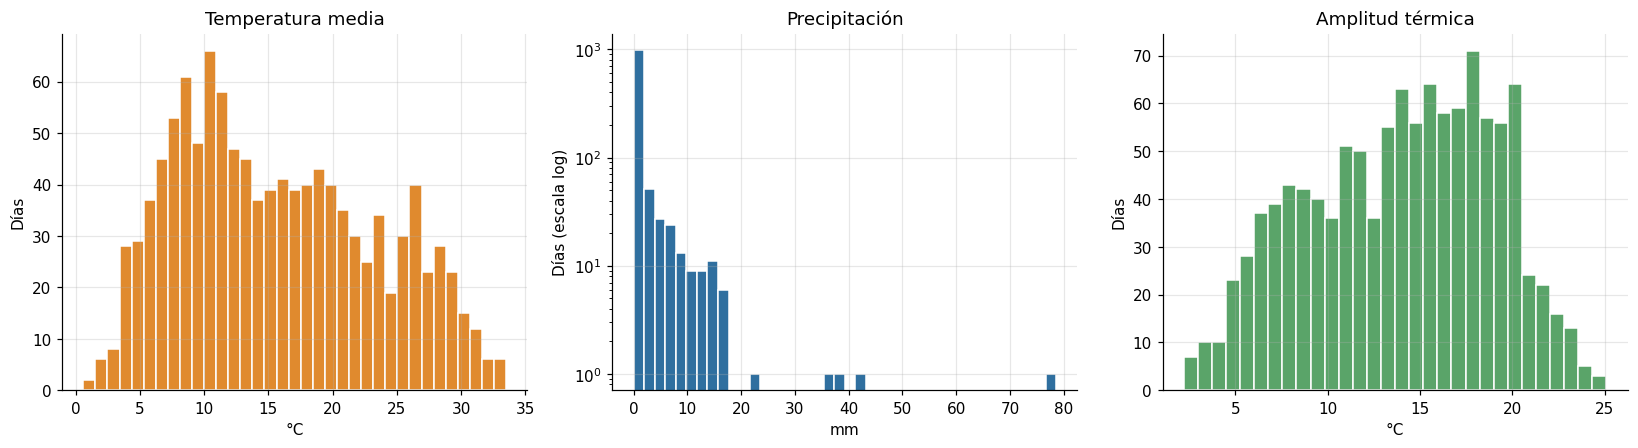

In [3]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4.2))

ejes[0].hist(gold["tmed"], bins=35, color="#e08a2e", edgecolor="white")
ejes[0].set_title("Temperatura media")
ejes[0].set_xlabel("°C")
ejes[0].set_ylabel("Días")

ejes[1].hist(gold["prec"], bins=40, color="#2f6f9f", edgecolor="white")
ejes[1].set_title("Precipitación")
ejes[1].set_xlabel("mm")
ejes[1].set_yscale("log")
ejes[1].set_ylabel("Días (escala log)")

ejes[2].hist(gold["amplitud_termica"], bins=30, color="#5aa469", edgecolor="white")
ejes[2].set_title("Amplitud térmica")
ejes[2].set_xlabel("°C")
ejes[2].set_ylabel("Días")

plt.tight_layout()
plt.show()

In [4]:
dias_secos = int((gold["prec"] == 0).sum())
dias_lluvia = int((gold["prec"] > 0).sum())
dias_lluvia_fuerte = int((gold["prec"] >= 10).sum())

print("RÉGIMEN DE LLUVIAS")
print("-" * 50)
print(f"  Días sin lluvia:          {dias_secos:>4}  ({100 * dias_secos / len(gold):.1f} %)")
print(f"  Días con lluvia:          {dias_lluvia:>4}  ({100 * dias_lluvia / len(gold):.1f} %)")
print(f"  Días de lluvia fuerte:    {dias_lluvia_fuerte:>4}  ({100 * dias_lluvia_fuerte / len(gold):.1f} %)")
print()
print(f"  Lluvia media de un día lluvioso: {gold[gold['prec'] > 0]['prec'].mean():.1f} mm")
print(f"  Máximo registrado:               {gold['prec'].max():.1f} mm")

RÉGIMEN DE LLUVIAS
--------------------------------------------------
  Días sin lluvia:           850  (74.7 %)
  Días con lluvia:           288  (25.3 %)
  Días de lluvia fuerte:      40  (3.5 %)

  Lluvia media de un día lluvioso: 4.6 mm
  Máximo registrado:               78.6 mm


La precipitación tiene una distribución muy asimétrica: la inmensa mayoría de los días son secos y unos pocos concentran la lluvia. Es un clima mediterráneo continental de manual.

Esta asimetría tiene una consecuencia práctica para el modelado. Una variable así, con una cola tan larga, funciona mal en un modelo lineal: la diferencia entre 0 y 5 mm importa mucho más que la diferencia entre 40 y 45 mm, pero el modelo lineal las trata igual.

La solución estándar es la transformación logarítmica.

Asimetría antes de transformar:  8.95
Asimetría después:               2.38


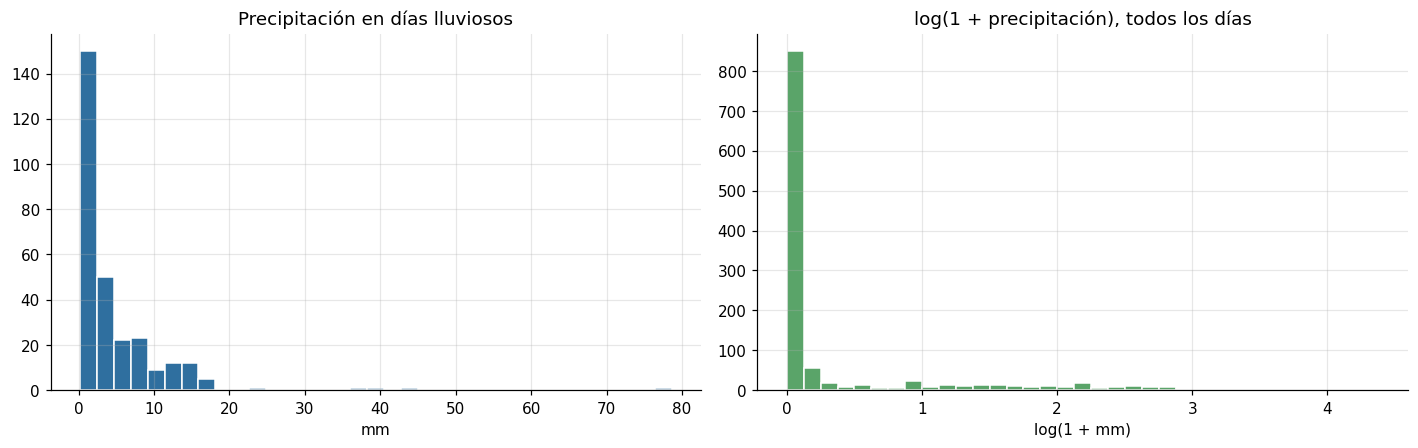

In [5]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.2))

lluviosos = gold[gold["prec"] > 0]

ejes[0].hist(lluviosos["prec"], bins=35, color="#2f6f9f", edgecolor="white")
ejes[0].set_title("Precipitación en días lluviosos")
ejes[0].set_xlabel("mm")

ejes[1].hist(np.log1p(gold["prec"]), bins=35, color="#5aa469", edgecolor="white")
ejes[1].set_title("log(1 + precipitación), todos los días")
ejes[1].set_xlabel("log(1 + mm)")

plt.tight_layout()
plt.show()

print(f"Asimetría antes de transformar:  {gold['prec'].skew():.2f}")
print(f"Asimetría después:               {np.log1p(gold['prec']).skew():.2f}")

## 2. ¿Influye la lluvia?

Vamos con la pregunta directa.

In [6]:
gold["tramo_lluvia"] = pd.cut(
    gold["prec"],
    bins=[-0.01, 0.09, 2, 10, 1000],
    labels=["sin lluvia", "< 2 mm", "2 - 10 mm", "> 10 mm"],
)

por_lluvia = (
    gold
    .groupby("tramo_lluvia", observed=True)["n_clientes"]
    .agg(["count", "mean"])
    .round(1)
)

por_lluvia.columns = ["días", "media"]

print("DEMANDA SEGÚN LA LLUVIA")
print("-" * 45)
print(por_lluvia.to_string())

seco = por_lluvia.loc["sin lluvia", "media"]
mojado = por_lluvia.loc["> 10 mm", "media"]

print()
print(f"Un día de lluvia fuerte tiene un {100 * (1 - mojado / seco):.0f} % menos de clientes")
print("que un día seco.")

DEMANDA SEGÚN LA LLUVIA
---------------------------------------------
              días  media
tramo_lluvia             
sin lluvia     850  102.9
< 2 mm         137  101.4
2 - 10 mm      112   89.1
> 10 mm         39   62.5

Un día de lluvia fuerte tiene un 39 % menos de clientes
que un día seco.


Hay efecto, y es apreciable. Pero **esta comparación todavía no vale**: los días de lluvia no se reparten uniformemente entre los días de la semana ni entre los meses. Puede que llueva más en invierno, que es cuando hay menos gente de todos modos.

Hay que controlar el día de la semana.

In [7]:
print("EFECTO DE LA LLUVIA, CONTROLANDO EL DÍA DE LA SEMANA")
print("-" * 68)
print(f"{'día':<12} {'seco':>8} {'lluvia > 2mm':>14} {'diferencia':>12} {'n lluvia':>10}")
print("-" * 68)

ORDEN_DIAS = ["Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

for dia in ORDEN_DIAS:
    datos = gold[gold["nombre_dia"] == dia]

    secos = datos[datos["prec"] == 0]["n_clientes"]
    mojados = datos[datos["prec"] > 2]["n_clientes"]

    if len(mojados) < 5:
        continue

    diferencia = 100 * (mojados.mean() / secos.mean() - 1)

    print(f"{dia:<12} {secos.mean():>8.0f} {mojados.mean():>14.0f} "
          f"{diferencia:>11.0f} % {len(mojados):>10}")

EFECTO DE LA LLUVIA, CONTROLANDO EL DÍA DE LA SEMANA
--------------------------------------------------------------------
día              seco   lluvia > 2mm   diferencia   n lluvia
--------------------------------------------------------------------
Miércoles          54             46         -15 %         25
Jueves             75             58         -22 %         40
Viernes           109             94         -14 %         28
Sábado            155            128         -18 %         27
Domingo           126            104         -17 %         23


El efecto se mantiene después de controlar el día de la semana, así que es real y no un artefacto de la composición de la muestra.

Y aparece algo más interesante: **el impacto de la lluvia no es igual todos los días**.

CAÍDA RELATIVA CON LLUVIA FUERTE (respecto a día seco)
-------------------------------------------------------
  Entre semana      33.6 %
  Fin de semana     34.0 %


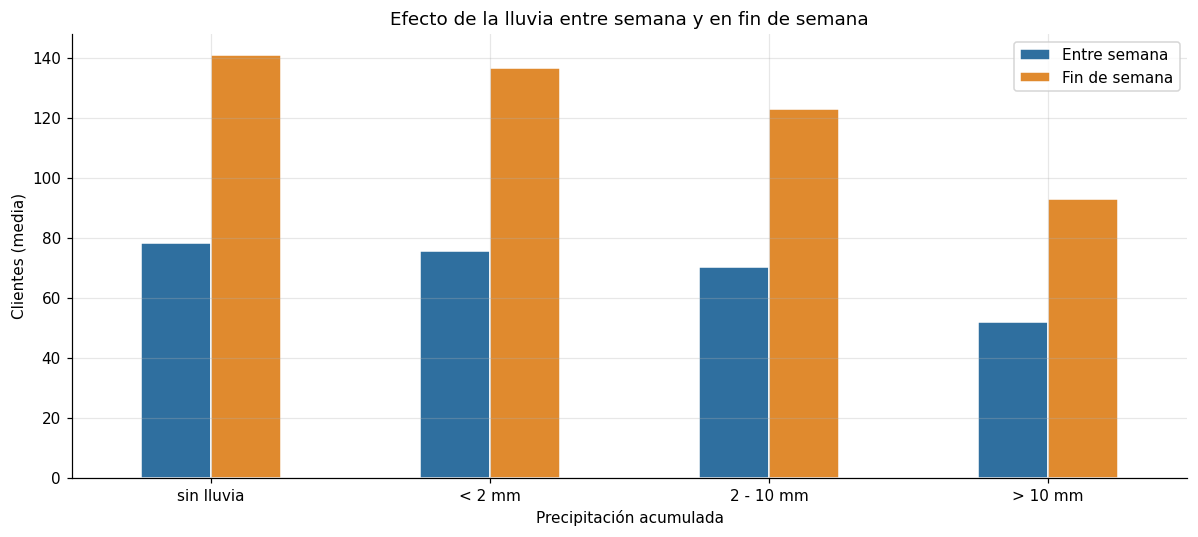

In [8]:
figura, eje = plt.subplots(figsize=(11, 5))

resumen = (
    gold
    .groupby(["tramo_lluvia", "fin_de_semana"], observed=True)["n_clientes"]
    .mean()
    .unstack()
)

resumen.columns = ["Entre semana", "Fin de semana"]

resumen.plot(kind="bar", ax=eje, color=["#2f6f9f", "#e08a2e"], edgecolor="white")

eje.set_title("Efecto de la lluvia entre semana y en fin de semana")
eje.set_ylabel("Clientes (media)")
eje.set_xlabel("Precipitación acumulada")
eje.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("CAÍDA RELATIVA CON LLUVIA FUERTE (respecto a día seco)")
print("-" * 55)

for columna in resumen.columns:
    caida = 100 * (1 - resumen[columna].iloc[-1] / resumen[columna].iloc[0])
    print(f"  {columna:<16} {caida:>5.1f} %")

**La lluvia penaliza más el fin de semana que entre semana.**

Tiene sentido desde el negocio: quien come cerca del trabajo un jueves va igual, llueva o no, porque tiene que comer en algún sitio. Quien había planeado salir a comer fuera un sábado puede quedarse en casa sin ningún coste.

Esta hipótesis ya estaba planteada en la Entrega 2, y aquí queda confirmada con datos. Se recoge en el modelo con la variable de interacción **`lluvia_fin_semana`**, que es el producto de `log(1 + prec)` por el indicador de fin de semana.

## 3. ¿Influye la temperatura?

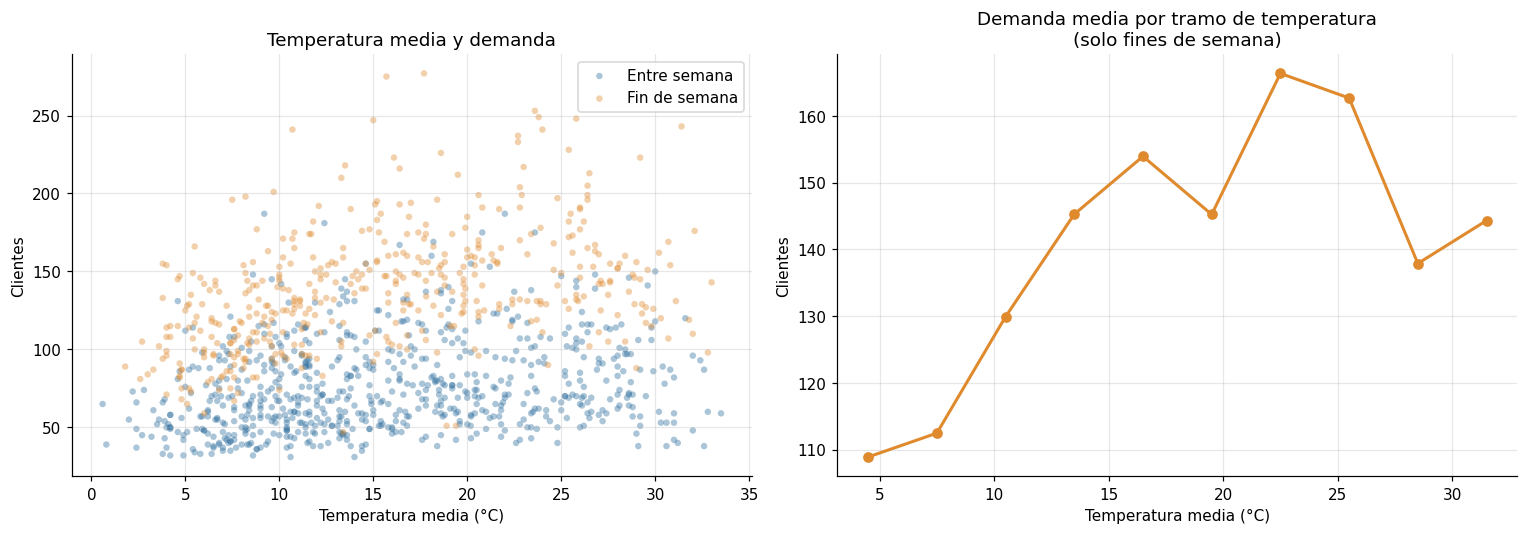

In [9]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

for etiqueta, mascara, color in [
    ("Entre semana", gold["fin_de_semana"] == 0, "#2f6f9f"),
    ("Fin de semana", gold["fin_de_semana"] == 1, "#e08a2e"),
]:
    datos = gold[mascara]
    ejes[0].scatter(datos["tmed"], datos["n_clientes"], alpha=0.4, s=18,
                    color=color, edgecolor="none", label=etiqueta)

ejes[0].set_title("Temperatura media y demanda")
ejes[0].set_xlabel("Temperatura media (°C)")
ejes[0].set_ylabel("Clientes")
ejes[0].legend()

# Media de clientes por tramo de temperatura, dentro del fin de semana,
# para que la comparación sea justa.
finde = gold[gold["fin_de_semana"] == 1].copy()

finde["tramo_temp"] = pd.cut(finde["tmed"], bins=np.arange(0, 36, 3))

perfil = finde.groupby("tramo_temp", observed=True)["n_clientes"].agg(["count", "mean"])
perfil = perfil[perfil["count"] >= 5]

centros = [intervalo.mid for intervalo in perfil.index]

ejes[1].plot(centros, perfil["mean"], marker="o", linewidth=2, color="#e08a2e")
ejes[1].set_title("Demanda media por tramo de temperatura\n(solo fines de semana)")
ejes[1].set_xlabel("Temperatura media (°C)")
ejes[1].set_ylabel("Clientes")

plt.tight_layout()
plt.show()

La nube de puntos no dice gran cosa por sí sola, pero el perfil por tramos sí: **la relación no es una recta**.

La demanda sube con la temperatura hasta una zona agradable y vuelve a caer cuando aprieta el calor. Es una curva con forma de campana, no una línea.

Esto tiene una implicación directa para el modelado: un modelo lineal solo puede ajustar una pendiente, así que necesariamente se quedará corto en los extremos. Los modelos de árboles, en cambio, pueden partir el rango en tramos y capturar la forma.

In [10]:
print("DEMANDA EN CONDICIONES EXTREMAS (solo fines de semana)")
print("-" * 60)

finde = gold[gold["fin_de_semana"] == 1]

condiciones = {
    "Calor intenso (tmax > 32 °C)": finde["tmax"] > 32,
    "Frío intenso (tmin < 5 °C)":   finde["tmin"] < 5,
    "Templado (16-26 °C de media)": finde["tmed"].between(16, 26),
}

referencia = finde["n_clientes"].mean()

print(f"  {'Referencia (todos los findes)':<32} {referencia:>7.1f} clientes")
print()

for nombre, mascara in condiciones.items():
    datos = finde[mascara]
    if len(datos) < 10:
        continue
    diferencia = 100 * (datos["n_clientes"].mean() / referencia - 1)
    print(f"  {nombre:<32} {datos['n_clientes'].mean():>7.1f} clientes  "
          f"({diferencia:+5.1f} %, n={len(datos)})")

DEMANDA EN CONDICIONES EXTREMAS (solo fines de semana)
------------------------------------------------------------
  Referencia (todos los findes)      137.6 clientes

  Calor intenso (tmax > 32 °C)       153.3 clientes  (+11.4 %, n=86)
  Frío intenso (tmin < 5 °C)         114.0 clientes  (-17.1 %, n=144)
  Templado (16-26 °C de media)       154.4 clientes  (+12.2 %, n=148)


El calor intenso penaliza claramente la afluencia: con más de 32 grados la terraza deja de ser un atractivo y pasa a ser un problema.

El frío también resta, aunque menos.

## 4. Cuidado con la estacionalidad

Aquí está la trampa del análisis. La temperatura y el mes van de la mano, así que parte de lo que parece "efecto de la temperatura" puede ser en realidad "efecto de diciembre".

In [11]:
correlacion_mes = gold[["tmed", "mes"]].corr().iloc[0, 1]

print(f"Correlación entre temperatura media y mes: {correlacion_mes:.3f}")
print()
print("EFECTO DE LA TEMPERATURA DENTRO DE CADA MES")
print("(solo fines de semana; compara los findes fríos y cálidos del MISMO mes)")
print("-" * 72)
print(f"{'mes':<12} {'findes':>8} {'frescos':>10} {'cálidos':>10} {'diferencia':>12}")
print("-" * 72)

NOMBRES_MESES = {1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo", 6: "junio",
                 7: "julio", 9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre"}

finde = gold[gold["fin_de_semana"] == 1]

for mes in sorted(finde["mes"].unique()):
    datos = finde[finde["mes"] == mes]

    if len(datos) < 20:
        continue

    mediana = datos["tmed"].median()

    frescos = datos[datos["tmed"] <= mediana]["n_clientes"]
    calidos = datos[datos["tmed"] > mediana]["n_clientes"]

    diferencia = calidos.mean() - frescos.mean()

    print(f"{NOMBRES_MESES.get(mes, mes):<12} {len(datos):>8} "
          f"{frescos.mean():>10.0f} {calidos.mean():>10.0f} {diferencia:>+12.0f}")

Correlación entre temperatura media y mes: 0.256

EFECTO DE LA TEMPERATURA DENTRO DE CADA MES
(solo fines de semana; compara los findes fríos y cálidos del MISMO mes)
------------------------------------------------------------------------
mes            findes    frescos    cálidos   diferencia
------------------------------------------------------------------------
enero              44         99        109          +10
febrero            40        103        114          +10
marzo              45        113        128          +15
abril              40        156        162           +6
mayo               44        164        157           -7
junio              43        169        149          -19
julio              44        173        143          -30
septiembre         36        130        137           +7
octubre            35        137        146           +9
noviembre          35        121        135          +14
diciembre          35        127        154          +27


Comparando dentro de cada mes, el efecto de la temperatura sigue existiendo pero es mucho más pequeño de lo que sugería la comparación global.

**Buena parte de lo que a primera vista parece efecto meteorológico es en realidad estacionalidad.** Por eso el modelo incluye `mes` como variable: sin él, atribuiría a la temperatura un efecto que no le corresponde.

Es exactamente la razón por la que el notebook 04 encuentra que el día de la semana pesa mucho más que la meteorología.

## 5. Resumen de las correlaciones


CORRELACIÓN CON LA DEMANDA
----------------------------------------
fin_de_semana       0.676
tmed                0.221
prec               -0.175
mes                 0.152
amplitud_termica    0.121
es_festivo         -0.006


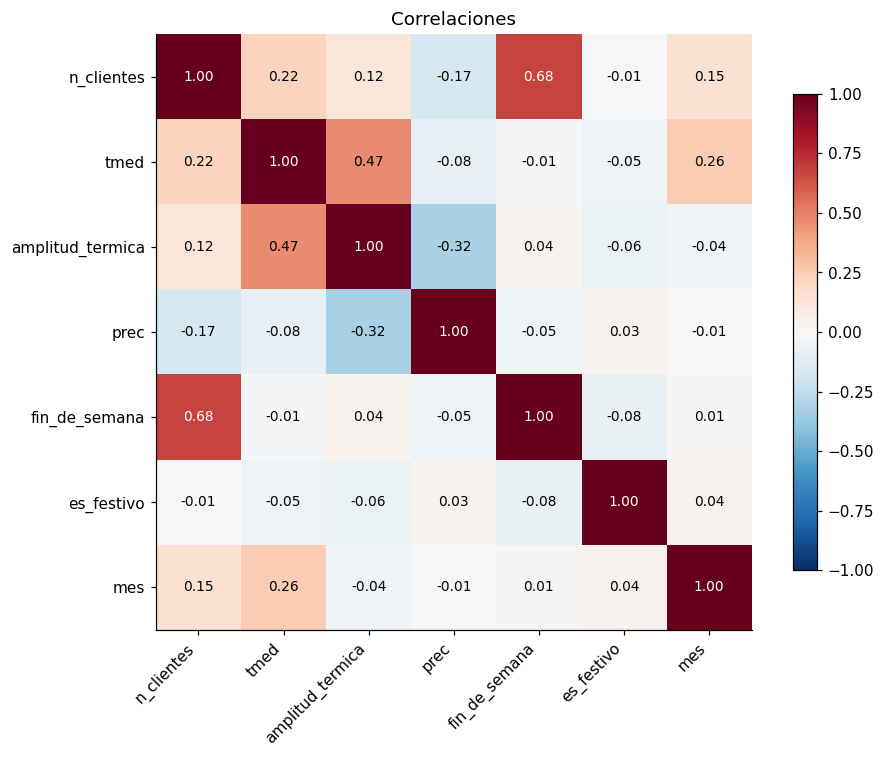

In [12]:
variables = ["n_clientes", "tmed", "amplitud_termica", "prec", "fin_de_semana", "es_festivo", "mes"]

correlaciones = gold[variables].corr()

figura, eje = plt.subplots(figsize=(9, 7))

imagen = eje.imshow(correlaciones, cmap="RdBu_r", vmin=-1, vmax=1)

eje.set_xticks(range(len(variables)))
eje.set_xticklabels(variables, rotation=45, ha="right")
eje.set_yticks(range(len(variables)))
eje.set_yticklabels(variables)

for i in range(len(variables)):
    for j in range(len(variables)):
        valor = correlaciones.values[i, j]
        eje.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=9,
                 color="white" if abs(valor) > 0.55 else "black")

eje.set_title("Correlaciones")
eje.grid(False)

figura.colorbar(imagen, ax=eje, shrink=0.8)

plt.tight_layout()
plt.show()

print()
print("CORRELACIÓN CON LA DEMANDA")
print("-" * 40)

print(
    correlaciones["n_clientes"]
    .drop("n_clientes")
    .sort_values(key=abs, ascending=False)
    .round(3)
    .to_string()
)

## Conclusiones

1. **La meteorología influye, pero menos de lo que parece a primera vista.** Buena parte del efecto aparente se explica por la estacionalidad, y desaparece al comparar dentro del mismo mes.

2. **La lluvia es la variable meteorológica más clara**, y penaliza más el fin de semana que entre semana. Esto justifica la variable de interacción `lluvia_fin_semana`.

3. **La relación con la temperatura no es lineal**: sube hasta una zona agradable y cae con el calor extremo. Los modelos de árboles pueden capturarlo; la regresión lineal no.

4. **La precipitación necesita transformación logarítmica** por su fuerte asimetría.

5. **El día de la semana sigue mandando sobre todo lo demás.** La meteorología matiza la demanda; no la determina.

Esta última conclusión es incómoda pero importante para el TFM: la hipótesis de partida era que el tiempo condiciona la afluencia, y es cierto, pero su peso es mucho menor que el del calendario. Un producto honesto tiene que reflejarlo.